In [1]:
# Import matplotlib to display images and plots.
import matplotlib.pyplot as plt

# Import pandas to read and work with CSV data files.
import pandas as pd

# Import NumPy for numerical operations and array reshaping.
import numpy as np

### Load Dataset

In [2]:
# Read the Fashion-MNIST training and testing CSV files.
# Each row contains one label followed by pixel values for a 28x28 image.
train_df = pd.read_csv('fashion-mnist_train.csv')
test_df = pd.read_csv('fashion-mnist_test.csv')

In [3]:
# Display the shape of the training dataset.
# This shows the number of training images and columns.
train_df.shape

(60000, 785)

In [4]:
# Display the shape of the testing dataset.
# This shows the number of test images and columns.
test_df.shape

(10000, 785)

In [5]:
# Show summary statistics for the training data.
# This helps understand the range and distribution of pixel values.
train_df.describe()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
count,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,...,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.00000
mean,4.500000,0.000900,0.006150,0.035333,0.101933,0.247967,0.411467,0.805767,2.198283,5.682000,...,34.625400,23.300683,16.588267,17.869433,22.814817,17.911483,8.520633,2.753300,0.855517,0.07025
std,2.872305,0.094689,0.271011,1.222324,2.452871,4.306912,5.836188,8.215169,14.093378,23.819481,...,57.545242,48.854427,41.979611,43.966032,51.830477,45.149388,29.614859,17.397652,9.356960,2.12587
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,4.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,58.000000,9.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,9.000000,16.000000,36.000000,226.000000,164.000000,227.000000,230.000000,224.000000,255.000000,254.000000,...,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,170.00000


In [6]:
# Display the unique class labels in the dataset.
# Fashion-MNIST has labels from 0 to 9.
train_df.label.unique()

array([2, 9, 6, 0, 3, 4, 5, 8, 7, 1])

#### Each row represents an grayscale image containing 784 pixels and each pixel having values in range from 0-255  
#### The column label is a discrete value in the range 0 to 9 each value representing a specific category

In [7]:
# Store the readable class names for each numeric label.
# For example, label 0 means T-shirt/top and label 1 means Trouser.
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat','Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

### Preprocess Data  
Convert each image of 784 into (28x28x1)(height x width x color_channels). Divide values by 255 to scale the values.

In [8]:
# Select all pixel columns from the training data and convert them to a NumPy array.
x_train = train_df.iloc[:,1:].to_numpy()

# Reshape the flat 784 pixel values into 28x28 grayscale images.
# The final 1 means there is one color channel.
x_train = x_train.reshape([-1,28,28,1])

# Scale pixel values from 0-255 to 0-1 so the model trains better.
x_train = x_train / 255

In [9]:
# Select the label column from the training data.
# These labels are the correct clothing categories for the training images.
y_train = train_df.iloc[:,0].to_numpy()

In [10]:
# Select all pixel columns from the test data and convert them to a NumPy array.
x_test = test_df.iloc[:,1:].to_numpy()

# Reshape the test images into 28x28 grayscale image format.
x_test = x_test.reshape([-1,28,28,1])

# Scale test pixel values from 0-255 to 0-1 using the same method as training data.
x_test = x_test / 255

In [11]:
# Select the label column from the test data.
# These labels are used to check the model's final performance.
y_test = test_df.iloc[:,0].to_numpy()

### Visualization

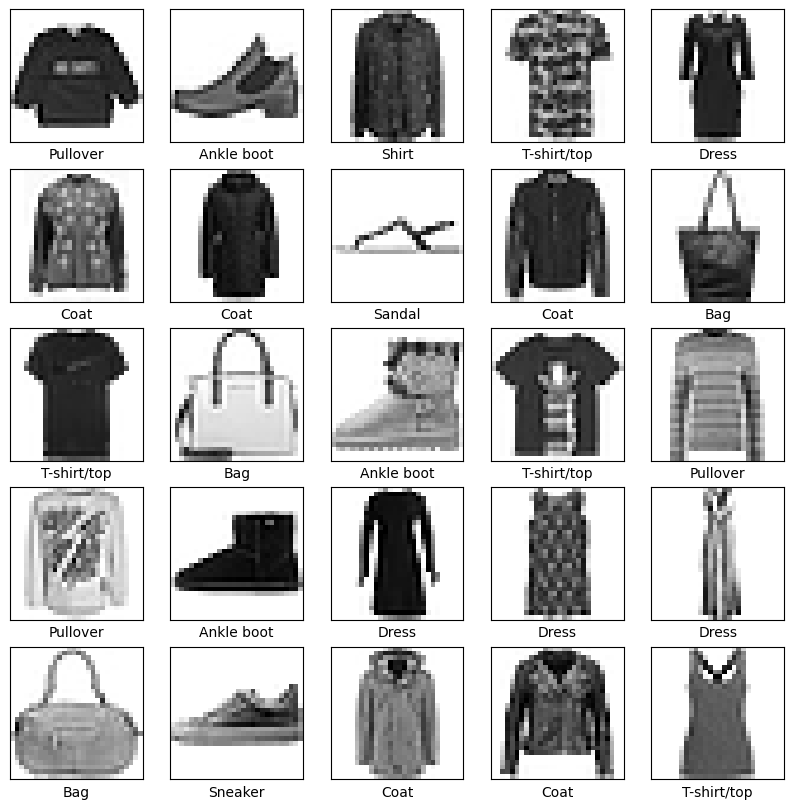

In [12]:
# Create a 10x10 inch figure to display sample training images.
plt.figure(figsize=(10,10))

# Display the first 25 training images in a 5x5 grid.
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[y_train[i]])

# Show the grid of images with their class names.
plt.show()

### Model Building

In [13]:
# Import Sequential to build the neural network layer by layer.
from keras.models import Sequential

# Import CNN and Dense layers used for image classification.
# Conv2D extracts image features, MaxPooling2D reduces image size,
# Dropout reduces overfitting, Flatten converts features to a vector,
# and Dense performs final classification.
from keras.layers import Dense,Conv2D,Flatten,MaxPooling2D,Dropout

In [14]:
# Create an empty Sequential CNN model.
model = Sequential()

# Add a convolution layer with 64 filters to detect image patterns.
# input_shape=(28,28,1) means images are 28x28 grayscale.
model.add(Conv2D(filters=64,kernel_size=(3,3),input_shape=(28,28,1),activation='relu'))

# Add max pooling to reduce feature size and keep important information.
model.add(MaxPooling2D(pool_size = (2,2)))

# Dropout turns off 30% of neurons during training to reduce overfitting.
model.add(Dropout(rate=0.3))

# Flatten the 2D feature maps into a 1D vector for Dense layers.
model.add(Flatten())

# Add a Dense hidden layer to learn classification patterns.
model.add(Dense(units=32, activation='relu'))

# Add the output layer with 10 neurons, one for each clothing class.
# Sigmoid gives class scores for the final prediction.
model.add(Dense(units=10, activation='sigmoid'))

# Compile the model with loss, optimizer, and accuracy metric.
# sparse_categorical_crossentropy is used because labels are integers from 0 to 9.
model.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

# Print the model structure and number of trainable parameters.
model.summary()

C:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 64)          │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 13, 13, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 10816)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │         346,144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 347,114 (1.32 MB)

 Trainable params: 347,114 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Train the CNN model using the training images and labels.
# epochs=50 means the model sees the full training data 50 times.
# batch_size=1200 means 1200 images are processed before each weight update.
# validation_split=0.05 keeps 5% of training data for validation.
model.fit(x_train,y_train,epochs=50,batch_size=1200,validation_split=0.05)

Epoch 1/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 12s 226ms/step - accuracy: 0.6992 - loss: 0.8941 - val_accuracy: 0.8067 - val_loss: 0.5294
Epoch 2/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 10s 216ms/step - accuracy: 0.8367 - loss: 0.4635 - val_accuracy: 0.8460 - val_loss: 0.4414
Epoch 3/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 11s 224ms/step - accuracy: 0.8580 - loss: 0.4044 - val_accuracy: 0.8650 - val_loss: 0.3899
Epoch 4/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 10s 216ms/step - accuracy: 0.8708 - loss: 0.3673 - val_accuracy: 0.8697 - val_loss: 0.3651
Epoch 5/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 12s 242ms/step - accuracy: 0.8776 - loss: 0.3486 - val_accuracy: 0.8800 - val_loss: 0.3440
Epoch 6/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 12s 251ms/step - accuracy: 0.8836 - loss: 0.3297 - val_accuracy: 0.8883 - val_loss: 0.3287
Epoch 7/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 11s 221ms/step - accuracy: 0.8893 - loss: 0.3127 - val_accuracy: 0.8903 - val_loss: 0.3141
Epoch 8/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 11s 231ms/step - accuracy: 0.8930 - loss: 0.3011 - val_accu

### Evaluation

In [16]:
# Evaluate the trained model on the test dataset.
# This returns the test loss and test accuracy.
evaluation = model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9225 - loss: 0.2214 


In [17]:
# Print the test accuracy in a readable format.
print(f"Accuracy: {evaluation[1]}")

Accuracy: 0.9225000143051147


In [18]:
# Predict class probabilities for all test images.
# Each row contains scores for the 10 clothing classes.
y_probas = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step  


In [19]:
# Convert prediction probabilities into final class labels.
# argmax selects the class with the highest score for each image.
y_pred = y_probas.argmax(axis=-1)

In [20]:
# Display the predicted class labels for the test images.
y_pred

array([0, 1, 2, ..., 8, 8, 1], shape=(10000,))

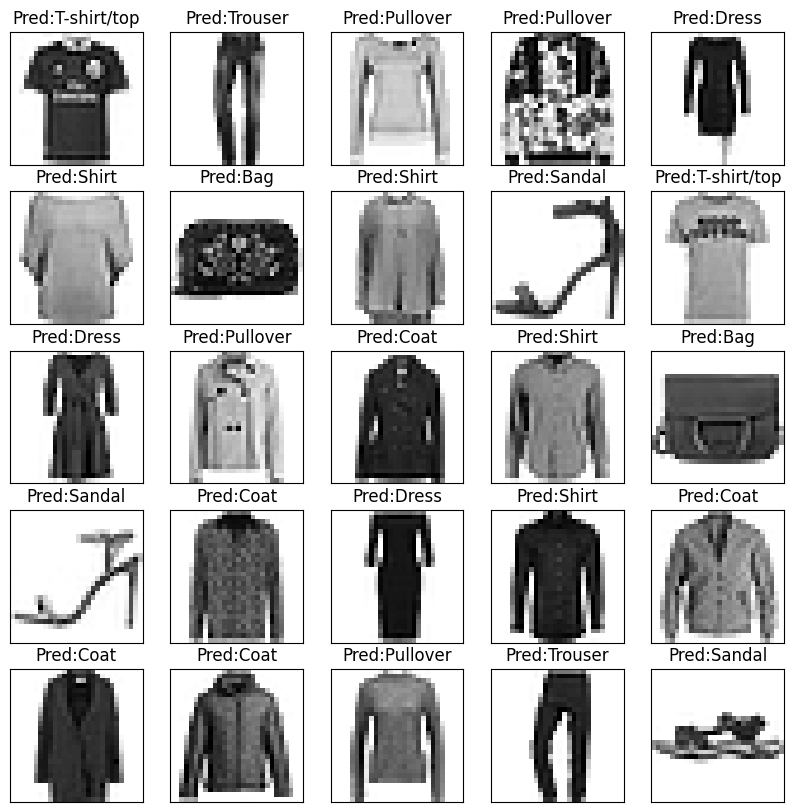

In [21]:
# Create a figure to display sample test images with predicted labels.
plt.figure(figsize=(10,10),)

# Show the first 25 test images in a 5x5 grid.
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_test[i], cmap=plt.cm.binary)
#     plt.xlabel(f"True Class:{y_test[i]}")
    plt.title(f"Pred:{class_names[y_pred[i]]}")

# Display the prediction grid.
plt.show()

In [22]:
# Import classification_report to show precision, recall, and F1-score.
from sklearn.metrics import classification_report

In [23]:
# Set the total number of Fashion-MNIST classes.
num_classes = 10

# Create simple class names for the classification report.
class_names = ["class {}".format(i) for i in range(num_classes)]

# Generate a detailed report comparing true labels with predicted labels.
cr = classification_report(y_test, y_pred, target_names=class_names)

# Print the classification report.
print(cr)

              precision    recall  f1-score   support

     class 0       0.86      0.86      0.86      1000
     class 1       0.98      0.99      0.98      1000
     class 2       0.90      0.87      0.88      1000
     class 3       0.91      0.94      0.93      1000
     class 4       0.88      0.91      0.89      1000
     class 5       0.98      0.98      0.98      1000
     class 6       0.79      0.76      0.77      1000
     class 7       0.96      0.97      0.96      1000
     class 8       0.98      0.98      0.98      1000
     class 9       0.97      0.97      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



In [ ]:
# This cell is intentionally left blank.

In [ ]:
# This cell is intentionally left blank.